Ola Uber Bookings EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Bookings.csv")

In [ ]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 9:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


In [ ]:
df.shape

(103024, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

In [ ]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Unnamed: 20'],
      dtype='object')

In [ ]:
df.dtypes

,0
Date,object
Time,object
Booking_ID,object
Booking_Status,object
Customer_ID,object
Vehicle_Type,object
Pickup_Location,object
Drop_Location,object
V_TAT,float64
C_TAT,float64


In [ ]:
df.describe()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Unnamed: 20
count,28800.000000,28800.000000,46373.000000,46373.000000,28800.000000,28800.000000,0.0
mean,171.038194,85.046354,548.392448,14.208527,3.998889,3.993438,NaN
std,80.462358,35.989200,535.623834,15.802636,0.576056,0.578811,NaN
min,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000,NaN
25%,98.000000,55.000000,241.000000,0.000000,3.500000,3.500000,NaN
50%,168.000000,85.000000,385.000000,8.000000,4.000000,4.000000,NaN
75%,238.000000,115.000000,623.000000,27.000000,4.500000,4.500000,NaN
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000,NaN


In [ ]:
df.describe(include='object') #For Categorical Values

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Payment_Method,Vehicle Images
count,103024,103024,103024,103024,103024,103024,103024,103024,10499,18434,63967,3926,63967,103024
unique,40214,1440,103024,4,94544,7,50,50,5,4,2,3,4,1
top,2024-07-01 20:09:00,00:53:00,CNR3204013257,Success,CID954071,Prime Sedan,Banashankari,Peenya,Driver is not moving towards pickup location,Personal & Car related issue,No,Customer Demand,Cash,#NAME?
freq,10,101,1,63967,5,14877,2201,2159,3175,6542,60041,1601,35022,103024


In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Booking_ID,0
Booking_Status,0
Customer_ID,0
Vehicle_Type,0
Pickup_Location,0
Drop_Location,0
V_TAT,39057
C_TAT,39057


In [ ]:
df = df.drop(['Unnamed: 20'], axis=1)

In [ ]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images'],
      dtype='object')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

/tmp/ipython-input-255/4183834281.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
df.shape

(103024, 20)

In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Time,datetime64[ns]
Booking_ID,object
Booking_Status,object
Customer_ID,object
Vehicle_Type,object
Pickup_Location,object
Drop_Location,object
V_TAT,float64
C_TAT,float64


In [ ]:
df['Booking_ID'] = df['Booking_ID'].astype('category')
df['Customer_ID'] = df['Customer_ID'].astype('category')

In [ ]:
df.drop(columns=['Vehicle Images'], inplace=True)

In [ ]:
df['Canceled_Rides_by_Customer'] = df['Canceled_Rides_by_Customer'].replace("Unknown", "No Cancellation")
df['Canceled_Rides_by_Driver'] = df['Canceled_Rides_by_Driver'].replace("Unknown", "No Cancellation")

In [ ]:
df['Incomplete_Rides'] = df['Incomplete_Rides'].fillna("No")

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  datetime64[ns]
 2   Booking_ID                  103024 non-null  category      
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  category      
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       103024 non-null  float64       
 9   C_TAT                       103024 non-null  float64       
 10  Canceled_Rides_by_Customer  103024 non-null  object        
 11  Canceled_Rides_by_Driver    103024 non-

,0
Date,0
Time,0
Booking_ID,0
Booking_Status,0
Customer_ID,0
Vehicle_Type,0
Pickup_Location,0
Drop_Location,0
V_TAT,0
C_TAT,0


In [ ]:
df['Canceled_Rides_by_Customer'].value_counts()

,count
Canceled_Rides_by_Customer,
No Cancellation,92525
Driver is not moving towards pickup location,3175
Driver asked to cancel,2670
Change of plans,2081
AC is Not working,1568
Wrong Address,1005


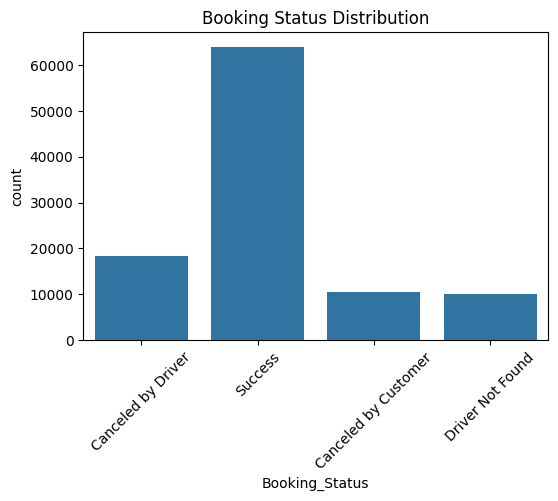

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Booking_Status', data=df)
plt.title("Booking Status Distribution")
plt.xticks(rotation=45)
plt.show()

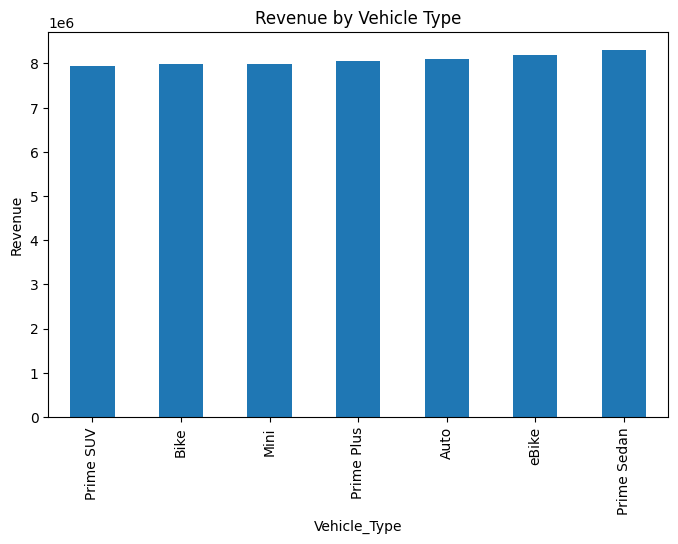

In [ ]:
plt.figure(figsize=(8,5))
df.groupby('Vehicle_Type')['Booking_Value'].sum().sort_values().plot(kind='bar')
plt.title("Revenue by Vehicle Type")
plt.ylabel("Revenue")
plt.show()

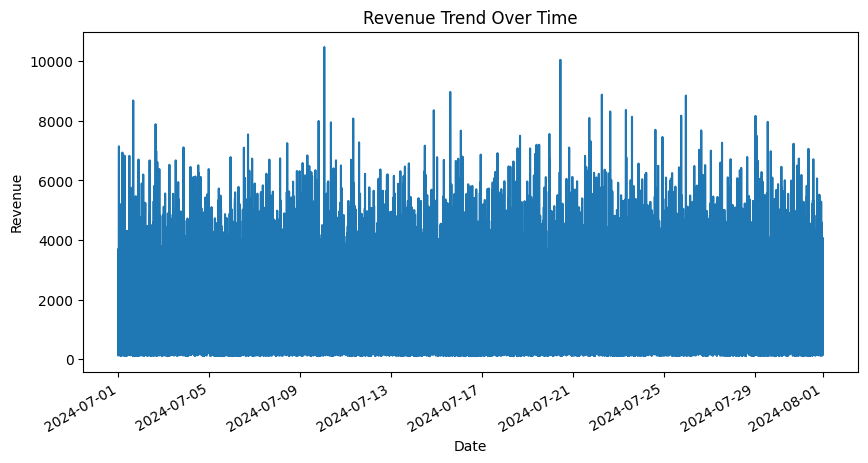

In [ ]:
daily_revenue = df.groupby('Date')['Booking_Value'].sum()

plt.figure(figsize=(10,5))
daily_revenue.plot()
plt.title("Revenue Trend Over Time")
plt.ylabel("Revenue")
plt.show()

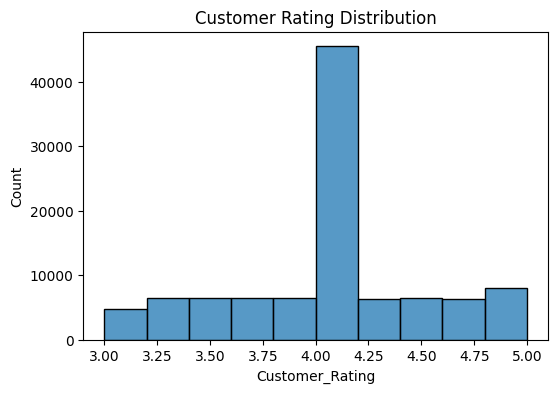

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Customer_Rating'], bins=10)
plt.title("Customer Rating Distribution")
plt.show()

In [ ]:
df.to_csv("Bookings_Cleaned.csv", index=False)